# Tratamento classificação
## Importação de bibliotecas básicas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

## Leitura e visualização do arquivo

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


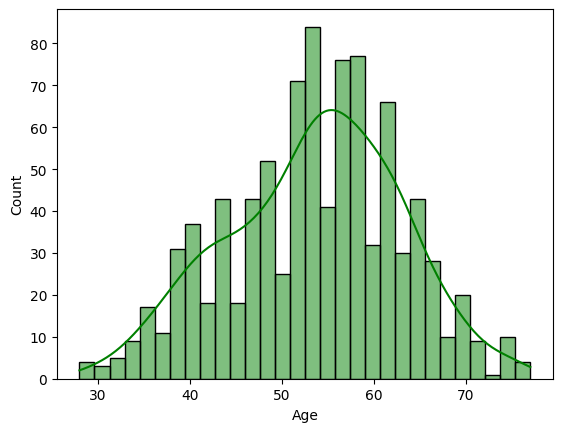

In [ ]:
dados = pd.read_csv("heart.csv" )
sns.histplot(dados, x='Age', bins=30, color='green', kde=True, stat='count')
dados.describe()

## Tratamento de dados nulos e zerados

Retirando linha com RestingBP = 0

In [3]:
dados2 = dados.loc[dados.RestingBP != 0]

Identificando linhas com Cholesterol = 0 e substituindo-as pela média (Não podem ser excluídas pois são muitas, o que faria com que grande parte dos dados "bons" de outras colunas se perdessem)

In [4]:
print(dados2['Cholesterol'].mean())
dados2.replace({'Cholesterol': 0}, np.nan, inplace=True)
print(dados2['Cholesterol'].mean())
# dados2.isnullº().sum()
dados2.fillna({'Cholesterol': dados2['Cholesterol'].mean()}, inplace=True)
dados2.describe()

199.0163576881134
244.6353887399464


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,244.635389,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.347125,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.635389,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Visualização de outliers

In [5]:
px.box(dados2, y='Age')

In [6]:
px.box(dados2, y='RestingBP')

In [7]:
px.box(dados2, y='Cholesterol')

In [8]:
px.box(dados2, y='MaxHR')

## Salvando dataframe tratado em novo arquivo para treinamento

In [9]:
dados2.to_csv('heart_tratado.csv', sep=',', encoding='utf-8', index=False)